# Task 1: Term Deposit Subscription Prediction (Bank Marketing)

## Problem Statement

Banks conduct marketing campaigns to encourage customers to subscribe to term deposits. Predicting whether a customer is likely to subscribe helps improve marketing efficiency and reduce unnecessary campaign costs.

## Objective

Develop machine learning models to predict whether a customer will subscribe to a term deposit using the Bank Marketing dataset. Compare multiple classification models and evaluate their performance using appropriate metrics. Finally, explain model predictions using Explainable AI (SHAP).

## Import Required Libraries

In [47]:
!pip install shap -q

In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    auc
)

import shap

plt.style.use("ggplot")

In [49]:
with open("bank-full.csv", "r") as file:
    for i in range(5):
        print(file.readline())

age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit

59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes

56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes

41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes

55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes



## Load Dataset

In [50]:
df = pd.read_csv("bank-full.csv")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Dataset Overview

In [51]:
df.shape

(11162, 17)

In [52]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [54]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [55]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


## Data Cleaning

In [56]:
# Check duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [57]:
# Remove duplicates
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (11162, 17)


## Exploratory Data Analysis (EDA)

In [58]:
df['deposit'].value_counts()

,count
deposit,
no,5873
yes,5289


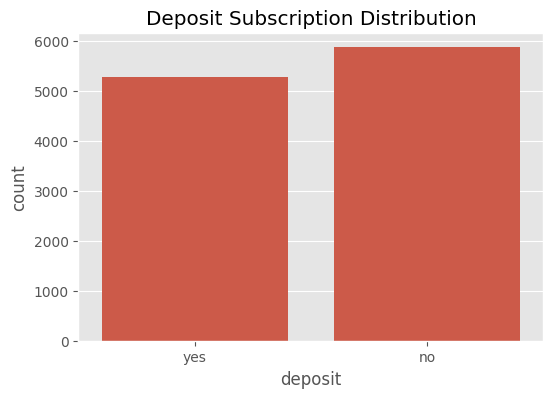

In [59]:
plt.figure(figsize=(6,4))
sns.countplot(x='deposit', data=df)

plt.title("Deposit Subscription Distribution")
plt.show()

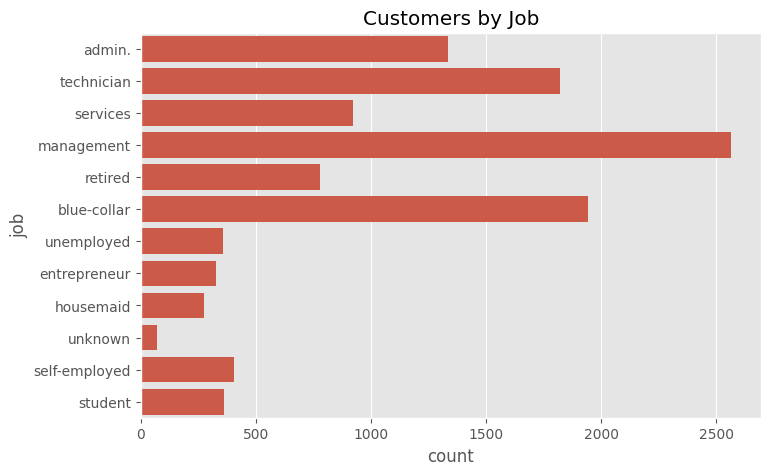

In [60]:
plt.figure(figsize=(8,5))
sns.countplot(y='job', data=df)

plt.title("Customers by Job")
plt.show()

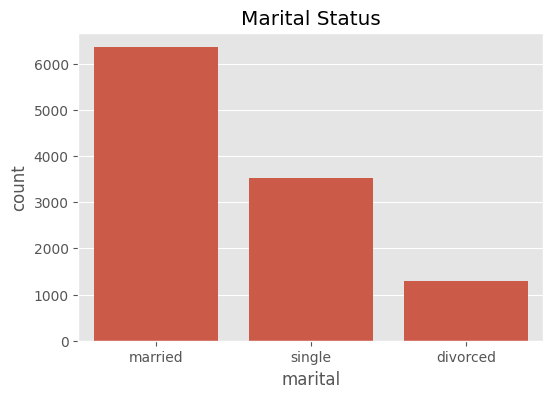

In [61]:
plt.figure(figsize=(6,4))
sns.countplot(x='marital', data=df)

plt.title("Marital Status")
plt.show()

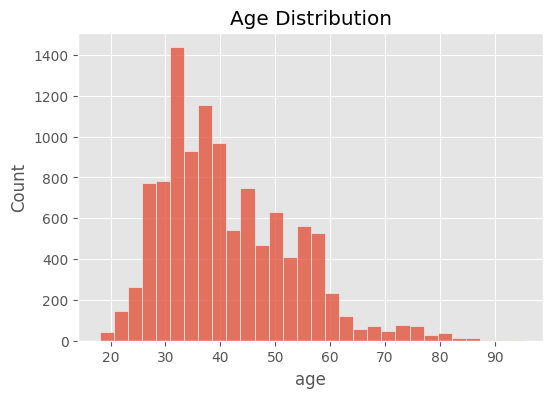

In [62]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30)

plt.title("Age Distribution")
plt.show()

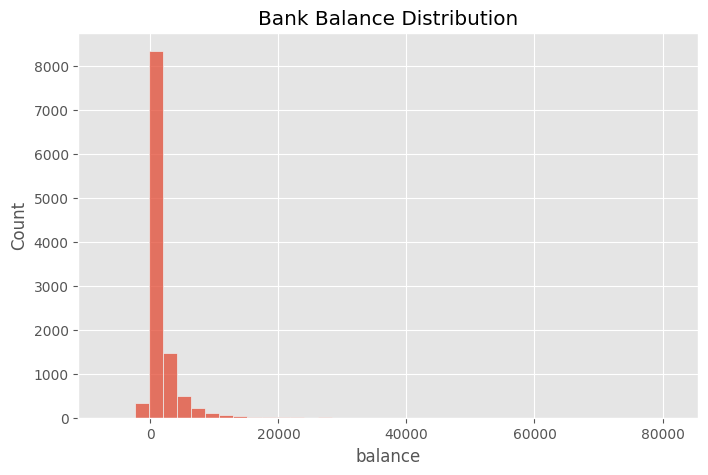

In [63]:
plt.figure(figsize=(8,5))
sns.histplot(df['balance'], bins=40)

plt.title("Bank Balance Distribution")
plt.show()

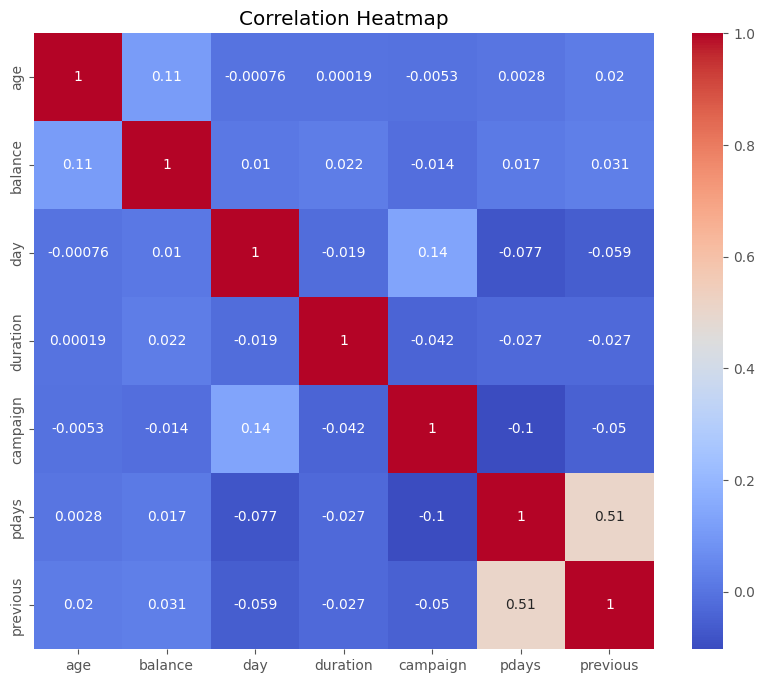

In [64]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

## Feature Encoding

In [65]:
df_encoded = df.copy()

encoder = LabelEncoder()

for column in df_encoded.columns:
    if df_encoded[column].dtype == 'object':
        df_encoded[column] = encoder.fit_transform(df_encoded[column])

df_encoded.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [66]:
df_encoded.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [67]:
print(df.shape)

(11162, 17)


## Train-Test Split

In [68]:
X = df_encoded.drop("deposit", axis=1)
y = df_encoded["deposit"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (11162, 16)
Target Shape: (11162,)


In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8929, 16)
(2233, 16)


## Logistic Regression Model

In [70]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [71]:
y_pred_lr = lr.predict(X_test)

In [72]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.7877295118674429


### Logistic Regression Performance

In [73]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80      1166
           1       0.78      0.77      0.78      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233



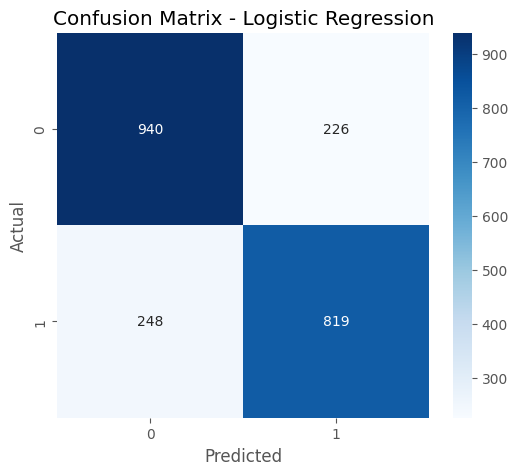

In [74]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [75]:
print("F1 Score:", f1_score(y_test, y_pred_lr))

F1 Score: 0.7755681818181818


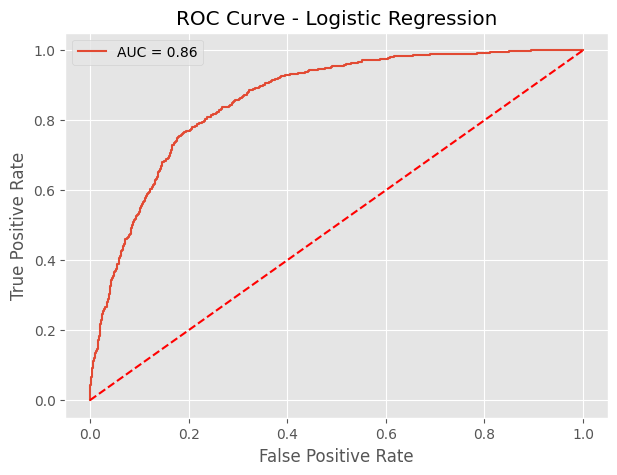

In [76]:
from sklearn.metrics import roc_curve, auc

y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

### Model Performance

The Logistic Regression model was trained to predict whether a customer would subscribe to a term deposit. The model's performance was evaluated using Accuracy, Confusion Matrix, Classification Report, F1-Score, and ROC Curve. These metrics provide a comprehensive understanding of the model's predictive capability.

## Random Forest Classifier

In [77]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [78]:
y_pred_rf = rf.predict(X_test)

In [79]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8334079713390058


In [80]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1166
           1       0.81      0.85      0.83      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



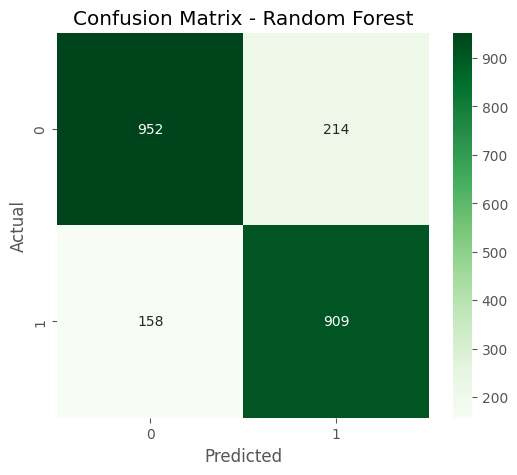

In [81]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [82]:
print("Random Forest F1 Score:", f1_score(y_test, y_pred_rf))

Random Forest F1 Score: 0.8301369863013699


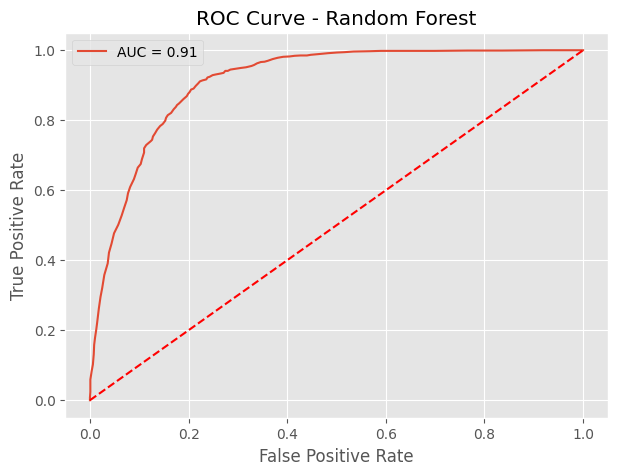

In [83]:
y_prob_rf = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

### Random Forest Performance

The Random Forest model was trained to predict whether a customer would subscribe to a term deposit. The model was evaluated using Accuracy, Confusion Matrix, Classification Report, F1-Score, and ROC Curve. Random Forest generally performs better than Logistic Regression because it combines multiple decision trees, improving prediction accuracy and reducing overfitting.

In [84]:
import shap

print(shap.__version__)

0.52.0


### Explainable AI (SHAP)

In [85]:
import shap

In [86]:
explainer = shap.Explainer(rf)

In [46]:
shap_values = explainer(X_test)

In [87]:
print(type(shap_values))
print(shap_values.values.shape)

<class 'shap._explanation.Explanation'>
(2233, 16, 2)


In [88]:
shap_values_yes = shap.Explanation(
    values=shap_values.values[:, :, 1],
    base_values=shap_values.base_values[:, 1],
    data=shap_values.data,
    feature_names=shap_values.feature_names
)

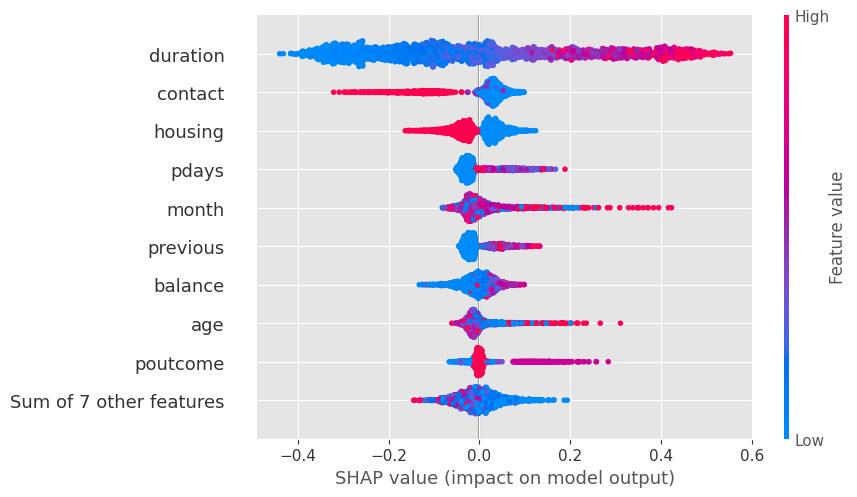

In [89]:
shap.plots.beeswarm(shap_values_yes)

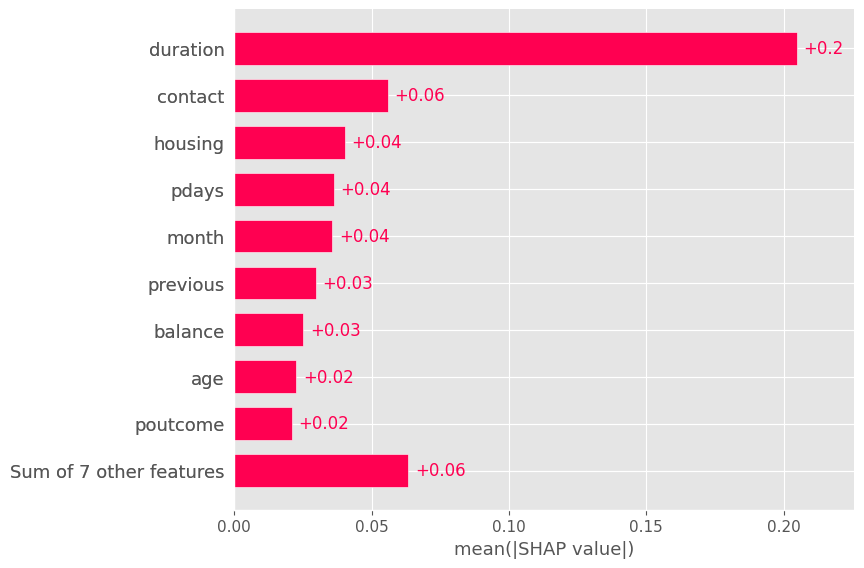

In [90]:
shap.plots.bar(shap_values_yes)

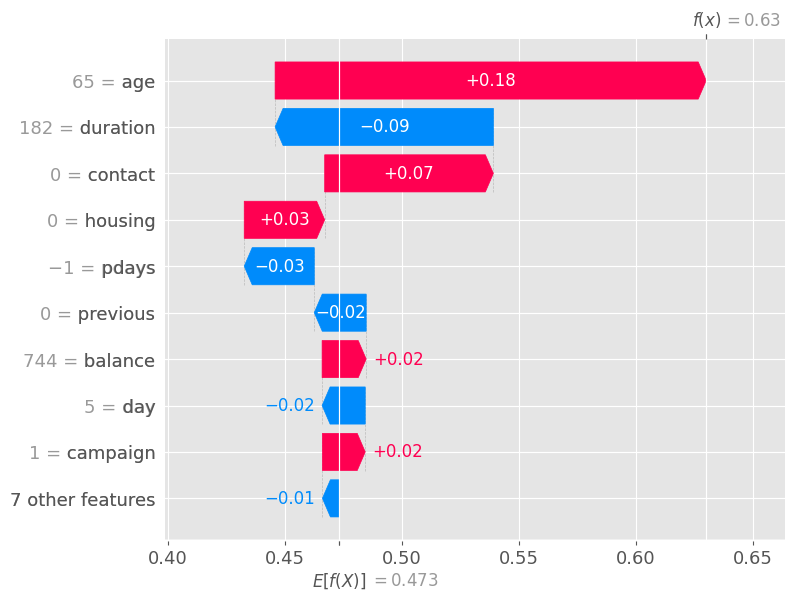

In [91]:
shap.plots.waterfall(shap_values_yes[0])

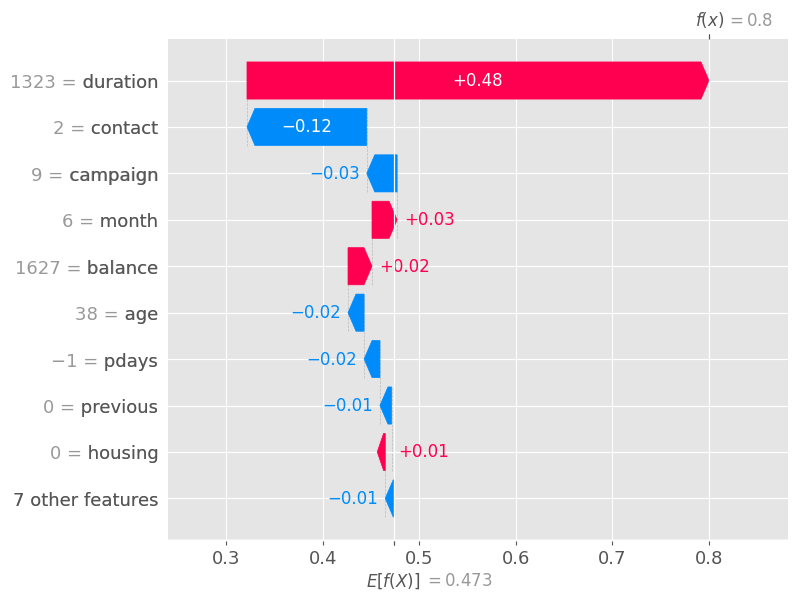

In [92]:
shap.plots.waterfall(shap_values_yes[1])

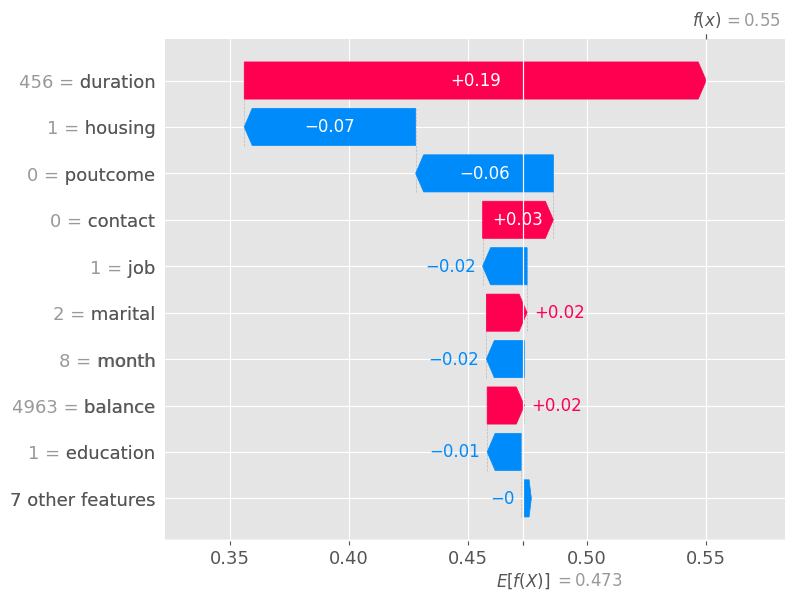

In [93]:
shap.plots.waterfall(shap_values_yes[2])

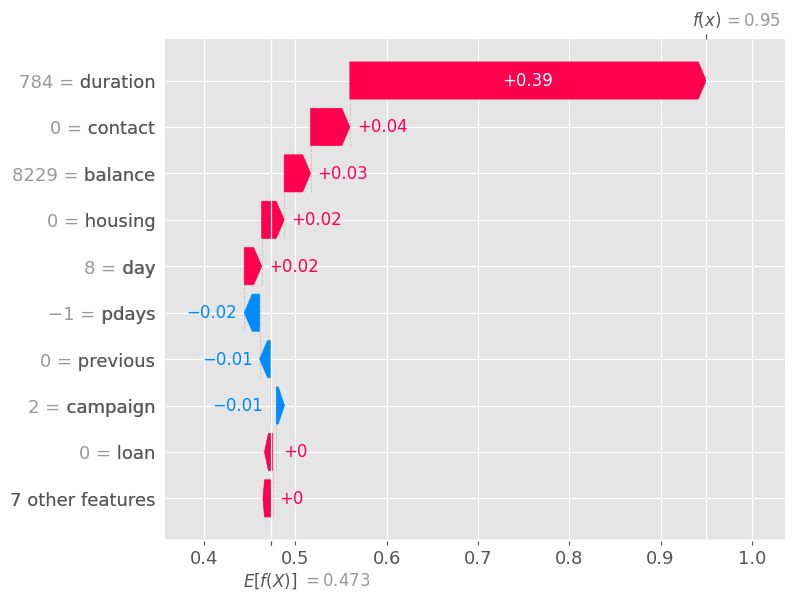

In [94]:
shap.plots.waterfall(shap_values_yes[3])

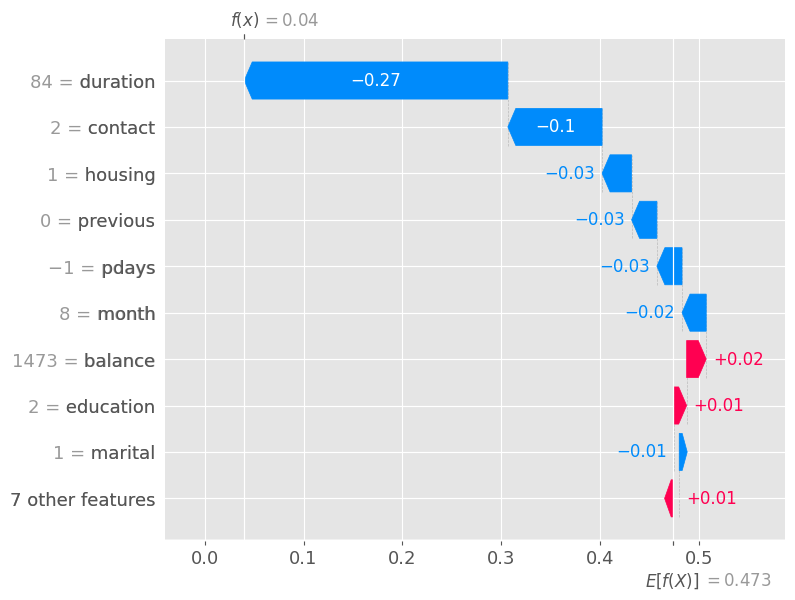

In [95]:
shap.plots.waterfall(shap_values_yes[4])

# Conclusion

In this project, the Bank Marketing dataset was analyzed to predict whether a customer would subscribe to a term deposit. After preprocessing and exploratory data analysis, Logistic Regression and Random Forest models were trained and evaluated.

Among the two models, **Random Forest** achieved the best performance with an **Accuracy of 83.34%** and an **F1-Score of 0.8301**, making it the preferred model for this classification task.

To improve model transparency, **SHAP (SHapley Additive exPlanations)** was used to explain the predictions of the Random Forest model. The SHAP visualizations highlighted the most influential features affecting customer subscription decisions, making the model easier to interpret.

Overall, this project demonstrated the complete machine learning workflow, including data preprocessing, exploratory data analysis, feature encoding, model training, evaluation, and explainable AI for better business decision-making.